# Polynomial Regression — Multiple Features

Demonstrates how gradient descent naturally emphasises
the correct polynomial feature when multiple are provided,
and how feature scaling enables faster convergence.

In [163]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

## Create Training Data

y = x² — a pure quadratic relationship.
Three features are created: x, x², x³.
Only x² is genuinely useful — gradient descent should discover this.

In [164]:
x = np.arange(0, 20, 1)
y = x**2
X = np.c_[x, x**2, x**3]

### Cost Function

Vectorised implementation using np.dot for multiple features.
Handles any number of input features through matrix operations.

In [165]:
def compute_cost(x, y, w, b):
    f_wb = (np.dot(x,w) + b )
    cost = (f_wb - y)**2
    total_cost = cost.mean()/2
    return total_cost

### Gradient Function

Vectorised gradient computation.
X.T @ error computes gradients for all weights simultaneously,
replacing the explicit j loop from the loop-based implementation.

In [166]:

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    f_wb = (np.dot(x,w) + b)
    error = (f_wb - y)
    dj_dw = (1/m)*(x.T@error)
    dj_db = error.mean()
    return dj_dw, dj_db

### Gradient Descent

Reusable optimisation loop — cost and gradient functions
passed as arguments to support different model types.

In [167]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_func, gradient_func):
    w = copy.deepcopy(w_in)
    b = b_in
    j_history = []
    
    for i in range(num_iter):
        dj_dw, dj_db = gradient_func(x, y, w, b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<(100000):
            j_history.append(cost_func(x,y,w,b))

        if i% math.ceil(num_iter / 10)==0:
            print(f"Iteration: {i:<8} cost:{j_history[-1]:12.6f}")

    return w,b, j_history

## Train on Raw Features

Without normalisation, alpha must be very small (1e-7)
to prevent divergence due to x³ values reaching into the thousands.

In [168]:
n = X.shape[1]
initial_w = np.zeros((n))
print(X)
initial_b = 0
alpha = 1e-7
iterations = 10000
w_final, b_final, cost = gradient_descent(X, y, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print(f"w: {w_final}, b: {b_final}")

[[   0    0    0]
 [   1    1    1]
 [   2    4    8]
 [   3    9   27]
 [   4   16   64]
 [   5   25  125]
 [   6   36  216]
 [   7   49  343]
 [   8   64  512]
 [   9   81  729]
 [  10  100 1000]
 [  11  121 1331]
 [  12  144 1728]
 [  13  169 2197]
 [  14  196 2744]
 [  15  225 3375]
 [  16  256 4096]
 [  17  289 4913]
 [  18  324 5832]
 [  19  361 6859]]
Iteration: 0        cost: 1140.292404
Iteration: 1000     cost:  328.539492
Iteration: 2000     cost:  280.443420
Iteration: 3000     cost:  239.388632
Iteration: 4000     cost:  204.344281
Iteration: 5000     cost:  174.430437
Iteration: 6000     cost:  148.895991
Iteration: 7000     cost:  127.099798
Iteration: 8000     cost:  108.494575
Iteration: 9000     cost:   92.613164
w: [0.08237526 0.53552137 0.02752216], b: 0.01056185052956357


Note the value of $\mathbf{w}$, `[0.08 0.54 0.02]` and b is `0.0105`.This implies the model after fitting/training is:
$$ 0.08x + 0.54x^2 + 0.02x^3 + 0.0105 $$
Gradient descent has emphasized the data that is the best fit to the $x^2$ data by increasing the $w_1$ term relative to the others.  If you were to run for a very long time, it would continue to reduce the impact of the other terms. 
>Gradient descent is picking the 'correct' features for us by emphasizing its associated parameter

Let's review this idea:
- less weight value implies less important/correct feature, and in extreme, when the weight becomes zero or very close to zero, the associated feature is not useful in fitting the model to the data.
- above, after fitting, the weight associated with the $x^2$ feature is much larger than the weights for $x$ or $x^3$ as it is the most useful in fitting the data.  

### Visualise Features Against Target

Plotting each feature against y reveals which transformation
produces a linear relationship with the target.
x² versus y should appear as a straight line.

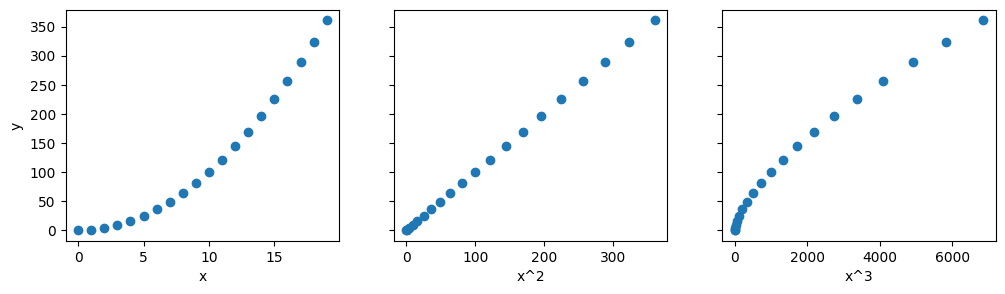

In [169]:
X_features = ['x','x^2','x^3']
fig, ax = plt.subplots(1, 3, figsize=(12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i], y)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('y')
plt.show()

Above, it is clear that the $x^2$ feature mapped against the target value $y$ is linear. Linear regression can then easily generate a model using that feature.

### Z-Score Normalisation

Raw polynomial features have vastly different scales —
x ranges 0-19, x² ranges 0-361, x³ ranges 0-6859.
Normalising brings all features to mean=0, std=1,
allowing a much larger learning rate and faster convergence.

In [170]:
def zscore_normalize(x):
    mu = x.mean(axis=0)
    sigma = x.std(axis=0)
    X_norm = (x - mu)/sigma
    return X_norm

In [171]:
x = np.arange(0,20,1)
X = np.c_[x, x**2, x**3]
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X,axis=0)}")

X = zscore_normalize(X)    
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X,axis=0)}\n")
print(X) 

Peak to Peak range by column in Raw        X:[  19  361 6859]
Peak to Peak range by column in Normalized X:[3.29501788 3.18076489 3.28307153]

[[-1.64750894 -1.08815641 -0.86396619]
 [-1.47408695 -1.07934543 -0.86348754]
 [-1.30066495 -1.05291248 -0.86013698]
 [-1.12724296 -1.00885756 -0.8510426 ]
 [-0.95382097 -0.94718068 -0.83333249]
 [-0.78039897 -0.86788183 -0.80413474]
 [-0.60697698 -0.77096102 -0.76057744]
 [-0.43355498 -0.65641824 -0.69978868]
 [-0.26013299 -0.52425349 -0.61889656]
 [-0.086711   -0.37446678 -0.51502915]
 [ 0.086711   -0.2070581  -0.38531456]
 [ 0.26013299 -0.02202746 -0.22688087]
 [ 0.43355498  0.18062515 -0.03685618]
 [ 0.60697698  0.40089973  0.18763144]
 [ 0.78039897  0.63879627  0.44945388]
 [ 0.95382097  0.89431478  0.75148306]
 [ 1.12724296  1.16745526  1.09659088]
 [ 1.30066495  1.4582177   1.48764927]
 [ 1.47408695  1.76660211  1.92753011]
 [ 1.64750894  2.09260848  2.41910534]]


## Train on Normalised Features

Same gradient descent, same functions —
but now alpha can be 1e-1 instead of 1e-7.
Observe how much faster cost drops and how much
more clearly x² dominates the final weights.

In [172]:
alpha = 1e-1
iterations = 100000
w_final, b_final, cost = gradient_descent(X, y, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print(f"w: {w_final}, b: {b_final}")

Iteration: 0        cost: 9421.466803
Iteration: 10000    cost:    0.390938
Iteration: 20000    cost:    0.027839
Iteration: 30000    cost:    0.001982
Iteration: 40000    cost:    0.000141
Iteration: 50000    cost:    0.000010
Iteration: 60000    cost:    0.000001
Iteration: 70000    cost:    0.000000
Iteration: 80000    cost:    0.000000
Iteration: 90000    cost:    0.000000
w: [5.26616827e-05 1.13494579e+02 8.43238778e-05], b: 123.49999999999994


### Plot — Normalised Model Prediction

Prediction plotted against original x values.
The model should fit the quadratic curve closely.

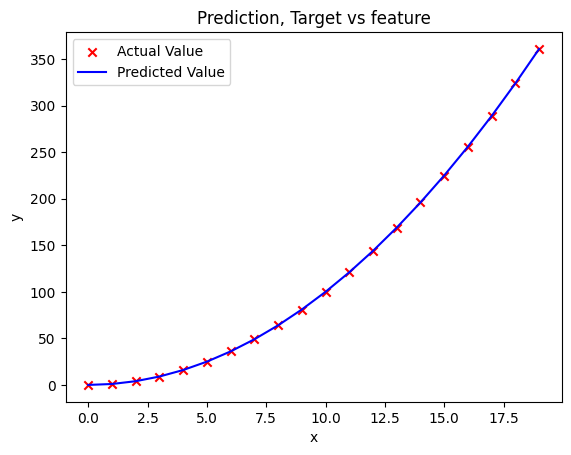

In [173]:
f_x = X@w_final + b_final #prediction
plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title("Prediction, Target vs feature")
plt.plot(x, f_x, c='b', label='Predicted Value'); plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.show()


Feature scaling allows this to converge much faster.   
Note again the values of $\mathbf{w}$. The $w_1$ term, which is the $x^2$ term is the most emphasized. Gradient descent has all but eliminated the $x^3$ term.

## Complex Function Approximation

Using 12 polynomial features, gradient descent can approximate
even non-polynomial functions like cos(x/2).
Each feature captures a different aspect of the curve.
The model needs 1,000,000 iterations to converge with this many features.

In [174]:
x = np.arange(0,20,1)
y = np.cos(x/2)

X = np.c_[x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10, x**11, x**12] 
X = zscore_normalize(X)

n = X.shape[1]
initial_w = np.zeros(n)
alpha = 1e-1
iterations = 1000000
model_w, model_b, cost = gradient_descent(X, y, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print(f"w: {model_w}, b: {model_b}")

Iteration: 0        cost:    0.220416
Iteration: 100000   cost:    0.018252
Iteration: 200000   cost:    0.018252
Iteration: 300000   cost:    0.018252
Iteration: 400000   cost:    0.018252
Iteration: 500000   cost:    0.018252
Iteration: 600000   cost:    0.018252
Iteration: 700000   cost:    0.018252
Iteration: 800000   cost:    0.018252
Iteration: 900000   cost:    0.018252
w: [ -1.49911121  -9.57965227  25.72624957   4.394509   -14.60906626
 -16.64725914  -7.40836414   4.29145881  11.99112134  12.22680223
   3.80415686 -13.0614822 ], b: -0.00728719485583907


### Plot — cos(x/2) Approximation

If the model converged, the predicted line should closely
follow the cosine curve despite using only polynomial features.

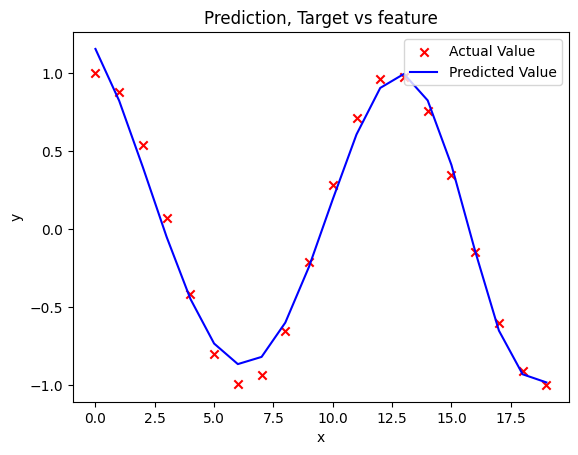

In [175]:
f_x = X@model_w + model_b #prediction
plt.scatter(x, y, marker='x', c='r', label='Actual Value'); plt.title("Prediction, Target vs feature")
plt.plot(x, f_x, c='b', label='Predicted Value'); plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.show()